In [ ]:
import pandas as pd
import numpy as np
import shap
import re
import csv
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, average_precision_score, auc, RocCurveDisplay
from sklearn.dummy import DummyClassifier

c:\Users\ankit\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_train_seqs_new.csv")
val_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_val_seqs_validation.csv")

In [3]:
seq_cols = ["CDR1 aligned", "CDR2 aligned", "CDR3 aligned"]
amino_acids = list("ACDEFGHIKLMNPQRSTVWY-")
add_position = True

In [ ]:
def concat_cdrs(row):
    return "".join(str(row[col]) for col in seq_cols)

train_df["CDRs"] = train_df.apply(concat_cdrs, axis=1)
val_df["CDRs"] = val_df.apply(concat_cdrs, axis=1)
train_lengths = train_df["CDRs"].str.len().iloc[0]
val_lengths = val_df["CDRs"].str.len().iloc[0]

assert train_lengths == val_lengths
assert (train_df["CDRs"].str.len() == train_lengths).all()
assert (val_df["CDRs"].str.len() == val_lengths).all()

In [5]:
print(train_lengths)

54


In [ ]:
aa2idx = {aa: i for i, aa in enumerate(amino_acids)}
I = np.eye(len(amino_acids),dtype=np.float32) 

In [ ]:
def one_hot_encode(seq, add_position=True, dtype=np.float32):
    feats = []
    for i, a in enumerate(seq):
        v =I[aa2idx.get(a, aa2idx["-"])] 
        if add_position:
            v = np.concatenate((v, [i/train_lengths])) 
        feats.append(v)
    return np.concatenate(feats, dtype=dtype)

In [7]:
x_train = np.vstack([one_hot_encode(seq, add_position, dtype=np.float32) for seq in train_df["CDRs"]])
y_train = train_df["Label"].values
x_val = np.vstack([one_hot_encode(seq, add_position, dtype=np.float32) for seq in val_df["CDRs"]])
y_val = val_df["Label"].values

In [ ]:
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,              
    min_samples_leaf=3,       
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)
clf.fit(x_train, y_train)
print("Number of features:", clf.n_features_in_)

Number of features: 1188


In [9]:
y_pred = clf.predict(x_val)
y_scores = clf.predict_proba(x_val)[:, 1]
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_val, clf.predict_proba(x_val)[:, 1]))

Accuracy: 0.5628676470588235
Precision: 0.5122273628552545
Recall: 0.632137030995106
F1 Score: 0.5658999634903249

Confusion Matrix:
 [[756 738]
 [451 775]]

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.51      0.56      1494
           1       0.51      0.63      0.57      1226

    accuracy                           0.56      2720
   macro avg       0.57      0.57      0.56      2720
weighted avg       0.57      0.56      0.56      2720


ROC AUC Score: 0.5994030499376517


In [ ]:
y_train_pred = clf.predict(x_train)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_pred))

Training Accuracy: 0.5917008719802324
Validation Accuracy: 0.5628676470588235


In [ ]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(x_train, y_train)
print("Baseline accuracy:", dummy.score(x_val, y_val))

Baseline accuracy: 0.549264705882353


In [12]:
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
ap = average_precision_score(y_val, y_scores)
print("Average precision:", ap)
pr_auc = auc(recall, precision)
print("PR AUC (AUC over PR curve):", pr_auc)

Average precision: 0.5428611949447572
PR AUC (AUC over PR curve): 0.5422302860880255


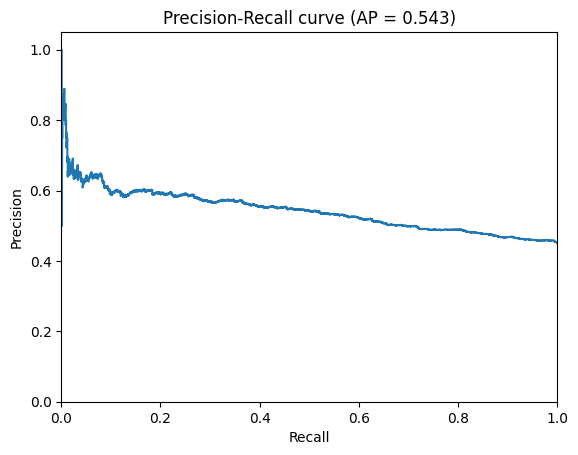

In [13]:
plt.figure()
plt.step(recall, precision, where="post")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall curve (AP = {ap:.3f})")
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()

Test evaluation

In [14]:
test_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_test_seqs_new.csv")
test_df["CDRs"] = test_df.apply(concat_cdrs, axis=1)
test_lengths = test_df["CDRs"].str.len().iloc[0]

In [ ]:
assert train_lengths == test_lengths
assert (test_df["CDRs"].str.len() == test_lengths).all()

In [16]:
x_test = np.vstack([one_hot_encode(seq, add_position, dtype=np.float32) for seq in test_df["CDRs"]])
y_test = test_df["Label"].values
clusters_test = test_df["Cluster_number"].values

In [17]:
val_test_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_val_seqs_test.csv")
val_test_df["CDRs"] = val_test_df.apply(concat_cdrs, axis=1)
val_test_lengths = val_test_df["CDRs"].str.len().iloc[0]
x_test_val = np.vstack([one_hot_encode(seq, add_position, dtype=np.float32) for seq in val_test_df["CDRs"]])
y_test_val = val_test_df["Label"].values
clusters_test_val = val_test_df["Cluster_number"].values

In [18]:
def evaluate_split(clf, x, y, split_name="Test"):
    y_scores = clf.predict_proba(x)[:, 1]
    y_pred = (y_scores >= 0.5).astype(int)

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    cm = confusion_matrix(y, y_pred)

    roc_auc = roc_auc_score(y, y_scores)
    p, r, _ = precision_recall_curve(y, y_scores)
    pr_auc = auc(r, p)

    print(f"\n================ FULL {split_name.upper()} SET ================\n")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1:        {f1:.3f}")
    print("\nConfusion matrix:")
    print(cm)
    print(f"\nROC-AUC:   {roc_auc:.3f}")
    print(f"PR-AUC:    {pr_auc:.3f}")

    return {
        "y_scores": y_scores,
        "y_pred": y_pred,
        "acc": acc,
        "prec": prec,
        "rec": rec,
        "f1": f1,
        "cm": cm,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    }



In [19]:

def evaluate_at_k(y_true, y_scores, clusters, k=100, split_name="Test"):
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)
    clusters = np.asarray(clusters)

    assert len(y_true) == len(y_scores), "y_true and y_scores must have same length"
    assert len(y_true) == len(clusters), "y_true and clusters must have same length"

    k = min(k, len(y_true))
    top_idx = np.argsort(y_scores)[::-1][:k]
    y_topk = y_true[top_idx]

    # precision@k
    precision_k = y_topk.sum() / k
    total_positives = y_true.sum()

    # precision@1000
    k_1000 = min(1000, len(y_true))
    top_idx_1000 = np.argsort(y_scores)[::-1][:k_1000]
    precision_1000 = y_true[top_idx_1000].sum() / k_1000

    # ef@k
    positive_rate = total_positives / len(y_true)
    ef_k = (precision_k / positive_rate) if positive_rate > 0 else np.nan

    # diversity@k
    diversity_k = len(np.unique(clusters[top_idx]))

    # normalized diversity@k
    total_unique_clusters = len(np.unique(clusters))
    normalized_diversity_k = (
        diversity_k / total_unique_clusters if total_unique_clusters > 0 else np.nan
    )
    
    print(f"\n================ {split_name.upper()} @ {k} ================\n")

    print(f"Precision@{k}:            {precision_k:.3f}")
    print(f"Precision@1000:           {precision_1000:.3f}")
    print(f"EF@{k}:                   {ef_k:.3f}" if not np.isnan(ef_k) else f"EF@{k}:NaN")

    print(f"Diversity@{k}:            {diversity_k}")
    print(f"Normalized Diversity@{k}: {normalized_diversity_k:.3f}" 
      if not np.isnan(normalized_diversity_k) 
      else f"Normalized Diversity@{k}: NaN")

    return {
        "top_idx": top_idx,
        f"precision@{k}": precision_k,
        f"precision@1000": precision_1000,
        f"ef@{k}": ef_k,
        f"diversity@{k}": diversity_k,
        f"normalized_diversity@{k}": normalized_diversity_k
    }


In [20]:
test_results = evaluate_split(clf, x_test, y_test, split_name="Test")
test_at_100 = evaluate_at_k(y_test, test_results["y_scores"], clusters_test, k=100, split_name="Test")

val_test_results = evaluate_split(clf, x_test_val, y_test_val, split_name="Validation")
val_test_at_100 = evaluate_at_k(y_test_val, val_test_results["y_scores"], clusters_test_val, k=100, split_name="Validation")




================ FULL TEST SET ================

Accuracy:  0.578
Precision: 0.555
Recall:    0.659
F1:        0.603

Confusion matrix:
[[ 9455  9376]
 [ 6049 11709]]

ROC-AUC:   0.614
PR-AUC:    0.602

================ TEST @ 100 ================

Precision@100:            0.820
Precision@1000:           0.763
EF@100:                   1.690
Diversity@100:            93
Normalized Diversity@100: 0.005

================ FULL VALIDATION SET ================

Accuracy:  0.569
Precision: 0.518
Recall:    0.607
F1:        0.559

Confusion matrix:
[[803 692]
 [481 744]]

ROC-AUC:   0.598
PR-AUC:    0.553

================ VALIDATION @ 100 ================

Precision@100:            0.710
Precision@1000:           0.539
EF@100:                   1.576
Diversity@100:            91
Normalized Diversity@100: 0.040


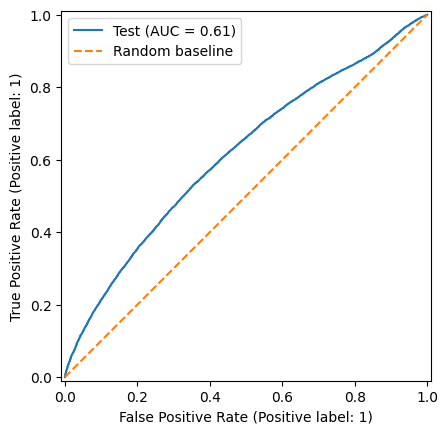

In [21]:
RocCurveDisplay.from_predictions(y_test, test_results["y_scores"], name="Test")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.legend()
plt.show()

In [ ]:
model_name = "RF_OHE_Positions"
seq_sim = 70

metrics_row = pd.DataFrame({
    "Model": [model_name],
    "Sequence_Similarity": [seq_sim],

    "Accuracy_test": [test_results["acc"]],
    "Precision_test": [test_results["prec"]],
    "Recall_test": [test_results["rec"]],
    "F1_test": [test_results["f1"]],
    "ROC_AUC_test": [test_results["roc_auc"]],
    "PR_AUC_test": [test_results["pr_auc"]],

    "Precision@100_test": [test_at_100["precision@100"]],
    "Precision@1000_test": [test_at_100["precision@1000"]],
    "EF@100_test": [test_at_100["ef@100"]],
    "Diversity@100_test": [test_at_100["diversity@100"]],
    "Normalized_Diversity@100_test": [test_at_100["normalized_diversity@100"]],

    "Precision@100_val": [val_test_at_100["precision@100"]],
    "Precision@1000_val": [val_test_at_100["precision@1000"]],
    "EF@100_val": [val_test_at_100["ef@100"]],
    "Diversity@100_val": [val_test_at_100["diversity@100"]],
    "Normalized_Diversity@100_val": [val_test_at_100["normalized_diversity@100"]],

    "N_test": [len(y_test)],
    "N_val": [len(y_test_val)]
})

metrics_file = r"D:\Thesis EGFR Round 3\Baseline Models\Results\metrics_all_models_70.csv"

metrics_row.to_csv(
    metrics_file,
    mode='a',
    header=not os.path.exists(metrics_file),
    index=False
)
print("Metrics saved.")



Metrics saved.


In [ ]:
def get_topk_df(df, y_true, y_scores, y_pred, top_idx):
    topk_df = df.iloc[top_idx].copy().assign(
        y_true=y_true[top_idx],
        pred_score=y_scores[top_idx],
        pred_label=y_pred[top_idx]
    )
    tp_topk_df = topk_df[
        (topk_df["y_true"] == 1) & (topk_df["pred_label"] == 1)
    ].copy()
    return tp_topk_df
tp_top100_df = get_topk_df(test_df, y_test, test_results["y_scores"], test_results["y_pred"], test_at_100["top_idx"])
export_df = tp_top100_df[[
    "Cluster_number",
    "Nanobody_id",
    "Label",
    "pred_label",
    "pred_score",
    "Sequence",
    "CDR1",
    "CDR2",
    "CDR3",
    "CDR1 aligned",
    "CDR2 aligned",
    "CDR3 aligned",
    "Aligned Sequence",
    "CDR_sequence"
]]

In [24]:
export_df.to_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\Predictions\regularized_position-aware_ohe.csv", index=False)
print("Saved only confident predictions to confident_predictions.csv")
print("Number of confident predictions:", len(export_df))

Saved only confident predictions to confident_predictions.csv
Number of confident predictions: 82


Total test samples: 36589
ANARCII CDR positions (L): 54
Total features D=1188
Channels per position n_channels=22 (AA channels=21, extras per pos=1)
SHAP matrix shape: (36589, 1188)
min/max shap: -0.07076830067647938 0.016465669881755705


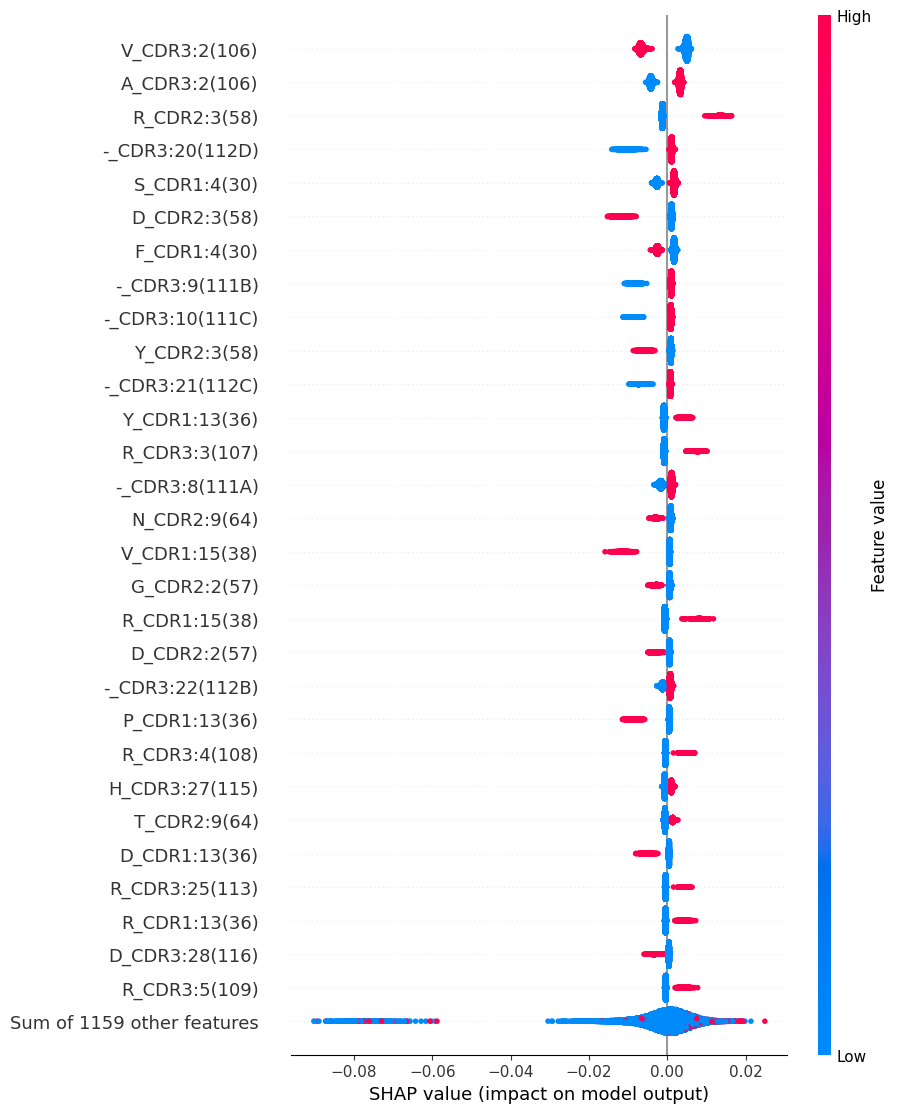


Top 20 features by |SHAP|:
        feature  mean_abs_SHAP
  V_CDR3:2(106)       0.005586
  A_CDR3:2(106)       0.003612
   R_CDR2:3(58)       0.002473
-_CDR3:20(112D)       0.002183
   S_CDR1:4(30)       0.002088
   D_CDR2:3(58)       0.002044
   F_CDR1:4(30)       0.002023
 -_CDR3:9(111B)       0.002021
-_CDR3:10(111C)       0.001925
   Y_CDR2:3(58)       0.001661
-_CDR3:21(112C)       0.001655
  Y_CDR1:13(36)       0.001523
  R_CDR3:3(107)       0.001482
 -_CDR3:8(111A)       0.001305
   N_CDR2:9(64)       0.001296
  V_CDR1:15(38)       0.001072
   G_CDR2:2(57)       0.001056
  R_CDR1:15(38)       0.001039
   D_CDR2:2(57)       0.000947
-_CDR3:22(112B)       0.000937


In [ ]:
rng = np.random.default_rng(0)
y_scores_test = clf.predict_proba(x_test)[:, 1]
print("Total test samples:", x_test.shape[0])
D = x_train.shape[1] if hasattr(x_train, "shape") else x_test.shape[1]
anarcii_path = r"D:\Thesis EGFR Round 3\Dataset\ANARCII\final_EG-ANARCII_imgt_wide_fixed_filtered.csv"

with open(anarcii_path, newline="") as f:
    reader = csv.reader(f)
    header = next(reader)  

def is_anarcii_col(c):
    return bool(re.fullmatch(r"\d+[A-Z]?", str(c)))

anarcii_cols_all = [c for c in header if is_anarcii_col(c)]

def num_part(c):
    m = re.match(r"(\d+)", str(c))
    return int(m.group(1)) if m else None

ranges = {
    "CDR1": (27, 38),
    "CDR2": (56, 65),
    "CDR3": (105, 117),
}

anarcii_cdr_cols = []   
cdr_names = []        

for col in anarcii_cols_all:
    n = num_part(col)
    found = None
    for name, (lo, hi) in ranges.items():
        if n is not None and lo <= n <= hi:
            found = name
            break
    if found is not None:
        anarcii_cdr_cols.append(col)
        cdr_names.append(found)

L = len(anarcii_cdr_cols)   
print("ANARCII CDR positions (L):", L)

if D % L != 0:
    raise ValueError(
        f"Feature dim D={D} is not divisible by number of CDR positions L={L}. "
        f"Check that your model really uses only these ANARCII positions."
    )

n_channels = D // L   

aa_alphabet = list("ACDEFGHIKLMNPQRSTVWY-")  
max_aa = len(aa_alphabet)

n_aa = min(n_channels, max_aa)
aa_list = aa_alphabet[:n_aa]

extra_per_pos = n_channels - n_aa  

print(f"Total features D={D}")
print(f"Channels per position n_channels={n_channels} (AA channels={n_aa}, extras per pos={extra_per_pos})")

feature_names = []
cdr_counters = {name: 0 for name in ranges.keys()}  

for cdr_name, anarcii_label in zip(cdr_names, anarcii_cdr_cols):
    cdr_counters[cdr_name] += 1
    cdr_label = f"{cdr_name}:{cdr_counters[cdr_name]}"  

    for aa in aa_list:
        feature_names.append(f"{aa}_{cdr_label}({anarcii_label})")

    for e in range(extra_per_pos):
        feature_names.append(f"Extra{e+1}_{cdr_label}({anarcii_label})")

assert len(feature_names) == D, (
    f"Feature name count mismatch: generated {len(feature_names)} names, but model has D={D} features. "
    "Check n_channels, L, and your encoding."
)

if isinstance(x_test, pd.DataFrame):
    X_test_df = x_test.copy()
    if X_test_df.shape[1] != D:
        raise ValueError(f"x_test has {X_test_df.shape[1]} columns, but expected D={D}.")
    X_test_df.columns = feature_names
else:
    
    X_test_df = pd.DataFrame(x_test, columns=feature_names)

explainer = shap.TreeExplainer(clf)
sv = explainer(X_test_df)


if isinstance(sv, shap.Explanation) and sv.values.ndim == 3:
    class_idx = 1
    sv = shap.Explanation(
        values=sv.values[:, :, class_idx],
        base_values=sv.base_values[:, class_idx],
        data=sv.data,
        feature_names=sv.feature_names
    )
elif isinstance(sv, list):
    sv = sv[1]

shap_values_matrix = sv.values if isinstance(sv, shap.Explanation) else sv

print("SHAP matrix shape:", shap_values_matrix.shape)
print("min/max shap:", shap_values_matrix.min(), shap_values_matrix.max())

if isinstance(sv, shap.Explanation):
    shap.plots.beeswarm(sv, max_display=30)
else:
    shap.summary_plot(shap_values_matrix, X_test_df, max_display=30)

mean_abs_shap = np.mean(np.abs(shap_values_matrix), axis=0)
feat_imp = (
    pd.DataFrame({"feature": feature_names, "mean_abs_SHAP": mean_abs_shap})
      .sort_values(by="mean_abs_SHAP", ascending=False)
)

print("\nTop 20 features by |SHAP|:")
print(feat_imp.head(20).to_string(index=False))

High-conf & label=1: 82


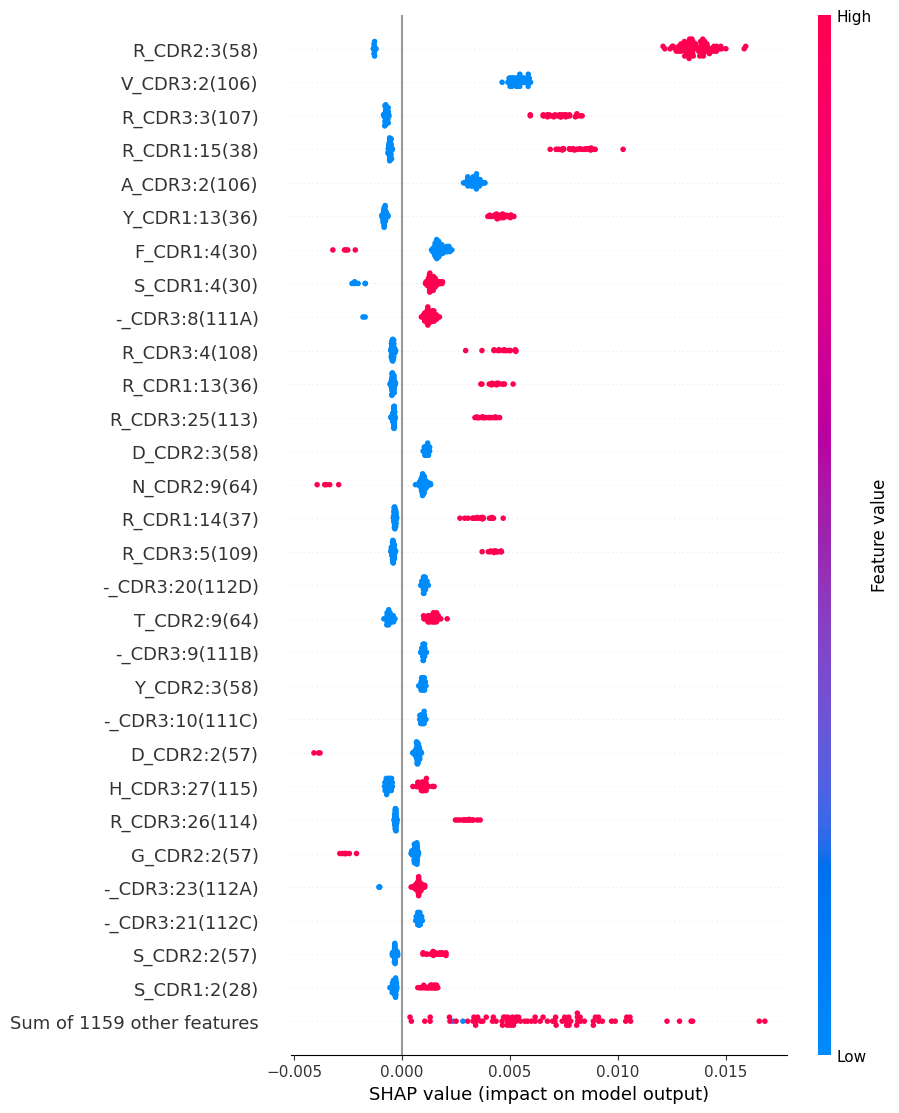

In [26]:
k_conf = 100
top_idx = np.argsort(-y_scores_test)[:k_conf]
top_pos_idx = top_idx[y_test[top_idx] == 1]

sv_conf_pos = sv[top_pos_idx]
X_conf_pos_df = X_test_df.iloc[top_pos_idx]

print("High-conf & label=1:", len(top_pos_idx))
shap.plots.beeswarm(sv_conf_pos, max_display=30)

In [ ]:
def anarcii_aa_heatmap(
    shap_values_matrix,  
    X_df,                
    feature_names,       
    aa_alphabet="ACDEFGHIKLMNPQRSTVWY-",
    agg="mean_abs",      
    drop_non_aa=True,    
    sort_positions=False
):

    pat = re.compile(r"^([A-Z\-])_.*\((\d+[A-Z]?)\)$")

    rows = []
    for j, fn in enumerate(feature_names):
        m = pat.match(fn)
        if not m:
            if drop_non_aa:
                continue
            else:
                continue
        aa, pos = m.group(1), m.group(2)
        if aa not in aa_alphabet:
            continue
        rows.append((j, pos, aa))

    if len(rows) == 0:
        raise ValueError("No AA-position features parsed. Check your feature name format.")

    idxs = np.array([r[0] for r in rows], dtype=int)
    pos_list = [r[1] for r in rows]
    aa_list  = [r[2] for r in rows]

    shap_sub = shap_values_matrix[:, idxs]
    X_sub    = X_df.iloc[:, idxs].to_numpy()

    if agg == "mean_abs":
        val = np.mean(np.abs(shap_sub), axis=0)
    elif agg == "mean_signed":
        val = np.mean(shap_sub, axis=0)
    elif agg == "pos_only_mean_abs":
        val = np.zeros(shap_sub.shape[1], dtype=float)
        for k in range(shap_sub.shape[1]):
            mask = X_sub[:, k] > 0.5
            val[k] = np.mean(np.abs(shap_sub[mask, k])) if mask.any() else 0.0
    else:
        raise ValueError("agg must be one of: mean_abs, mean_signed, pos_only_mean_abs")

    df_long = pd.DataFrame({"pos": pos_list, "aa": aa_list, "val": val})
    pos_order = list(dict.fromkeys(pos_list)) 

    heat = df_long.pivot_table(
    index="pos", columns="aa", values="val", aggfunc="mean", fill_value=0.0
    )
    heat = heat.reindex(pos_order)
    aa_order = [a for a in aa_alphabet if a in heat.columns]
    heat = heat.reindex(columns=aa_order)

    plt.figure(figsize=(max(8, 0.35*len(aa_order)), max(6, 0.25*heat.shape[0])))
    im = plt.imshow(heat.to_numpy(), aspect="auto")
    plt.colorbar(im, label=f"SHAP ({agg})")

    plt.xticks(np.arange(len(aa_order)), aa_order, rotation=0)
    plt.yticks(np.arange(heat.shape[0]), heat.index)

    plt.xlabel("Amino acid")
    plt.ylabel("ANARCII / IMGT position")
    plt.title("ANARCII position × amino acid SHAP heatmap")
    plt.tight_layout()
    plt.show()

    return heat  

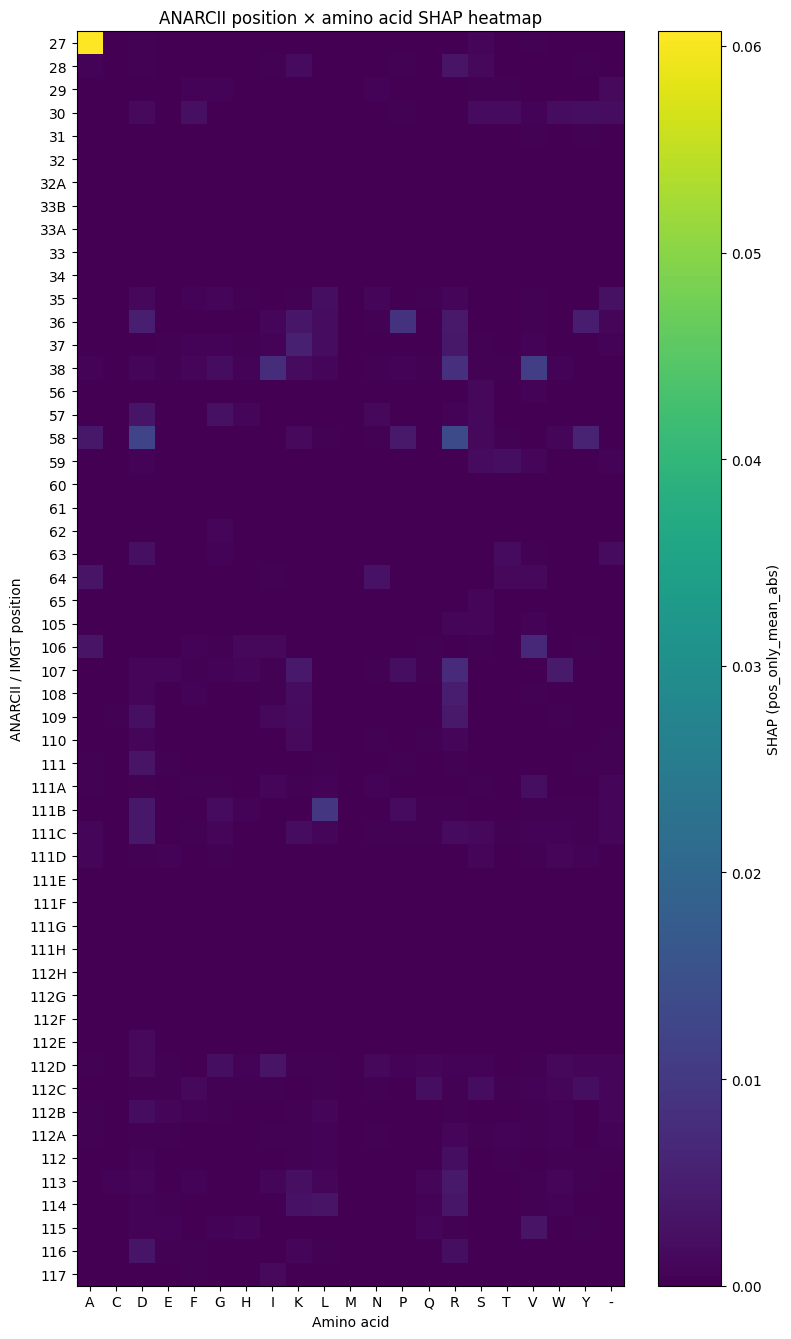

In [35]:
heat = anarcii_aa_heatmap(
    shap_values_matrix=shap_values_matrix,
    X_df=X_test_df,
    feature_names=feature_names,
    agg="pos_only_mean_abs"   
)

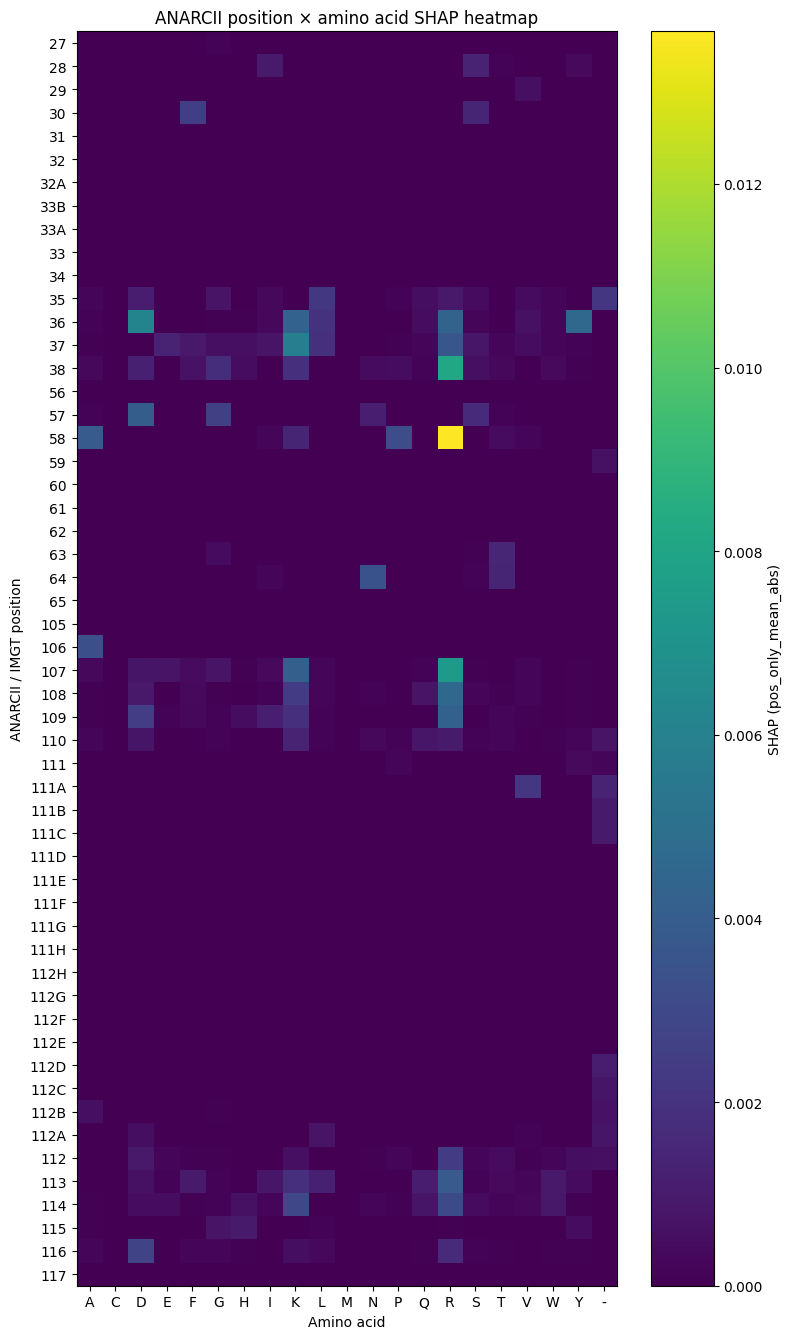

In [36]:
k_conf = 100
top_idx = np.argsort(-y_scores_test)[:k_conf]

heat_conf = anarcii_aa_heatmap(
    shap_values_matrix=shap_values_matrix[top_idx],
    X_df=X_test_df.iloc[top_idx],
    feature_names=feature_names,
    agg="pos_only_mean_abs"
)

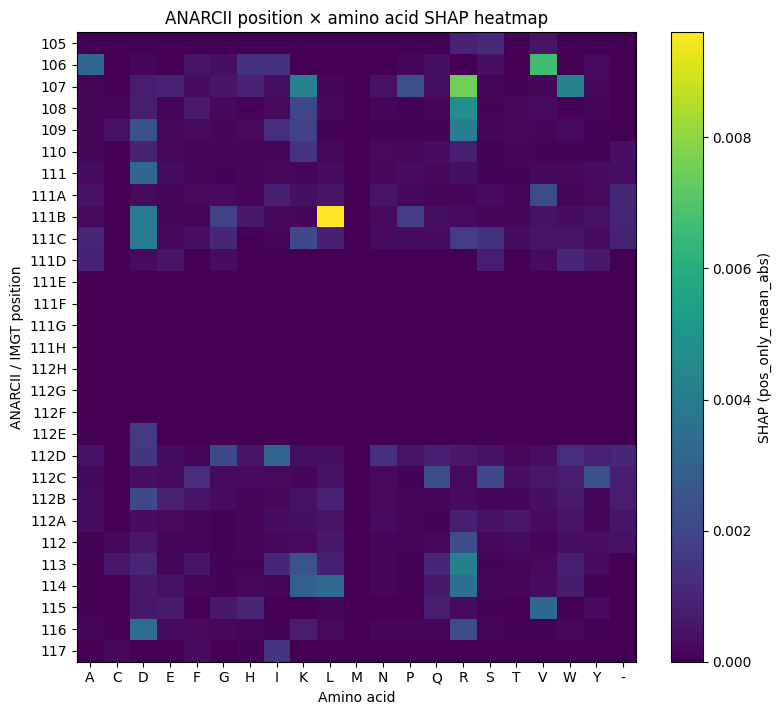

In [37]:
cdr3_positions = set([str(p) for p in anarcii_cdr_cols if num_part(p) is not None and 105 <= num_part(p) <= 117])

pos_pat = re.compile(r"\((\d+[A-Z]?)\)$")
keep_cols = []
keep_names = []
for j, fn in enumerate(feature_names):
    m = pos_pat.search(fn)
    if m and m.group(1) in cdr3_positions:
        keep_cols.append(j)
        keep_names.append(fn)

heat_cdr3 = anarcii_aa_heatmap(
    shap_values_matrix=shap_values_matrix[:, keep_cols],
    X_df=X_test_df.iloc[:, keep_cols],
    feature_names=keep_names,
    agg="pos_only_mean_abs"
)